# Caso 2 — Stroke Prevention Analytics (Salud)


## 1. Contexto y Objetivo
El objetivo de este proyecto es doble:
1. **Regresión:** Estimar el nivel medio de glucosa (`avg_glucose_level`) de un paciente como indicador clínico preliminar.
2. **Clasificación:** Predecir el riesgo de sufrir un derrame cerebral (`stroke`) para aplicar medidas preventivas.

**Supuesto de Negocio y Leakage Clínico:** Para evitar la fuga de información (data leakage), asumimos que las variables `avg_glucose_level` y `bmi` representan mediciones tomadas en un chequeo de rutina preventivo, meses o años antes de un posible derrame. Si estas métricas se tomaran durante el evento (hiperglucemia por estrés del derrame), el modelo sería inválido para la prevención. Asimismo, la categoría `Unknown` en el estado de fumador se conservará, ya que la falta de historial clínico es un factor de riesgo per se.

### 1. Supuestos Clínicos y Justificación de Leakage

In [22]:
# ==========================================
# 1. IMPORTACIONES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y Pipelines
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Modelos y Métricas
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import confusion_matrix, recall_score, roc_auc_score, RocCurveDisplay

# Configuración visual
sns.set_theme(style="whitegrid")

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
# ==========================================
# 2. CARGA DE DATOS
# ==========================================

df = pd.read_csv('/content/drive/MyDrive/caso de estudio machine/healthcare-dataset-stroke-data.csv')



In [25]:
# Eliminamos la columna 'id' porque es un identificador único sin valor predictivo
df = df.drop(columns=['id'])

# Mostramos las primeras 5 filas
display(df.head())


# Vemos los tipos de datos y valores nulos
print("\n--- Información del Dataset ---")
df.info()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1



--- Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


Justificación de Supuestos y Leakage:

Leakage Clínico (avg_glucose_level): Si la glucosa se midió en el momento exacto del derrame, usarla sería data leakage (hiperglucemia por estrés). Así que Asumiremos que los datos provienen de historiales médicos previos (chequeos de rutina) y no del momento del evento. Bajo este escenario preventivo, la variable es válida.

Valores Nulos en bmi: Se imputarán usando la mediana poblacional dentro del pipeline para evitar fuga de información desde el conjunto de prueba hacia el de entrenamiento.

Categoría smoking_status = Unknown: Se mantendrá como una categoría válida. En el ámbito clínico, la falta de información es en sí misma un dato (puede indicar falta de seguimiento médico regular), por lo que no la imputaremos.

/tmp/ipykernel_148/4176858903.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stroke', data=df, palette='viridis')


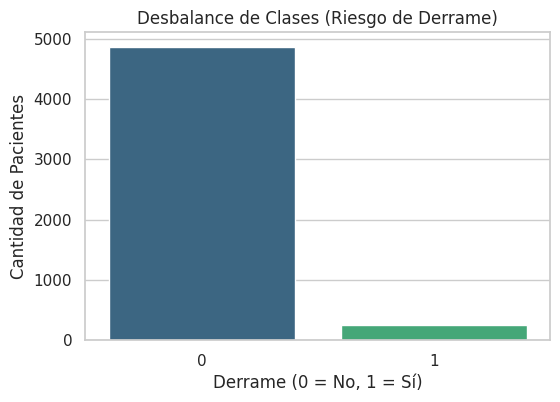

Pacientes sin derrame (0): 95.13%
Pacientes con derrame (1): 4.87%


In [26]:
# ==========================================
# 3.1. DISTRIBUCIÓN DEL TARGET (STROKE)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='stroke', data=df, palette='viridis')
plt.title('Desbalance de Clases (Riesgo de Derrame)')
plt.ylabel('Cantidad de Pacientes')
plt.xlabel('Derrame (0 = No, 1 = Sí)')
plt.show()

# Calcular proporción exacta
proporcion = df['stroke'].value_counts(normalize=True) * 100
print(f"Pacientes sin derrame (0): {proporcion[0]:.2f}%")
print(f"Pacientes con derrame (1): {proporcion[1]:.2f}%")

"El gráfico de barras muestra un severo desbalance de clases en nuestro dataset. Aproximadamente el 95% de los pacientes no han sufrido un derrame cerebral, mientras que solo el 5% sí. Esto es un comportamiento normal en datos médicos, pero nos advierte que usar la métrica de 'Accuracy' (Exactitud) será engañoso, y deberemos aplicar técnicas de balanceo de pesos (class_weight) durante el entrenamiento de nuestro modelo de clasificación."

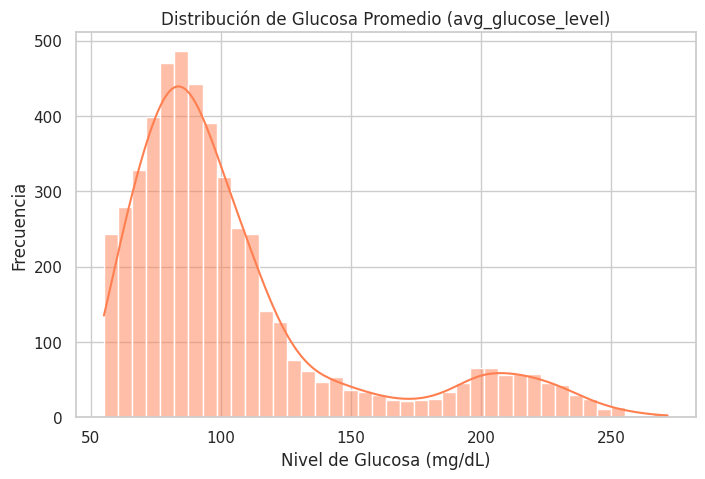

In [27]:
# ==========================================
# 3.2. DISTRIBUCIÓN DE LA GLUCOSA
# ==========================================
plt.figure(figsize=(8, 5))
sns.histplot(df['avg_glucose_level'], bins=40, kde=True, color='coral')
plt.title('Distribución de Glucosa Promedio (avg_glucose_level)')
plt.xlabel('Nivel de Glucosa (mg/dL)')
plt.ylabel('Frecuencia')
plt.show()

El histograma revela una distribución bimodal (dos 'picos'). La gran mayoría de los pacientes tienen niveles normales de glucosa (concentrados entre 60 y 120 mg/dL). Sin embargo, existe una 'cola' alargada hacia la derecha con un segundo pico menor alrededor de los 200-250 mg/dL, lo que claramente representa a la población con diabetes o prediabetes. Esta asimetría nos indica que la predicción lineal será un desafío para los valores extremos.

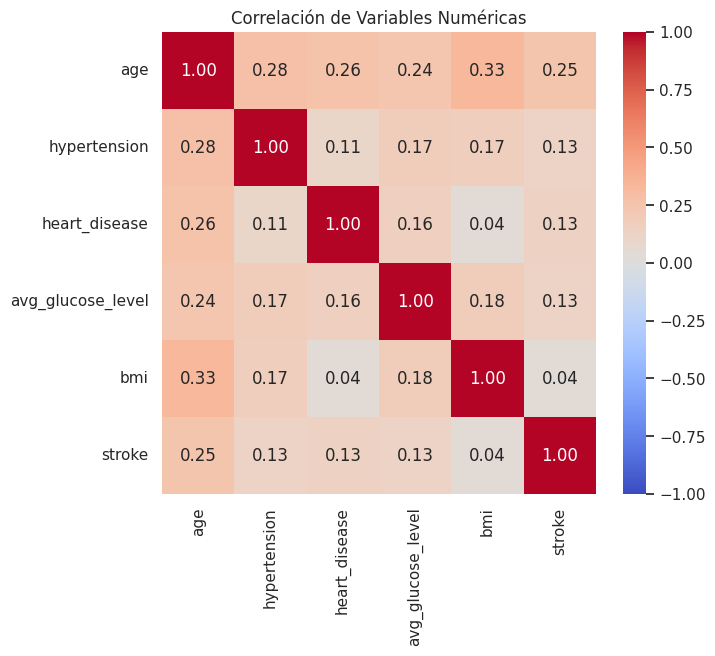


--- Calidad del Dato: Valores Nulos ---
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [28]:
# ==========================================
# 3.3. MATRIZ DE CORRELACIÓN NUMÉRICA
# ==========================================
plt.figure(figsize=(7, 6))

# Seleccionamos solo las columnas numéricas
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[num_cols].corr()

# Generamos el mapa de calor
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlación de Variables Numéricas')
plt.show()

# Mostramos también los valores nulos como parte de la calidad del dato
print("\n--- Calidad del Dato: Valores Nulos ---")
print(df.isnull().sum())

El mapa de calor de correlaciones de Pearson analiza nuestras variables predictoras numéricas. Como se puede observar en la gráfica, no existen correlaciones lineales fuertes entre ellas; la relación más alta se da entre la edad (`age`) y el índice de masa corporal (`bmi`) con un valor de apenas **0.33**. Esto es una excelente noticia, ya que descarta por completo problemas de multicolinealidad severa, lo que permitirá que nuestros modelos lineales interpreten el impacto de cada variable de forma independiente y estable.

En cuanto a la calidad general de los datos, el análisis previo confirma que la única columna con valores nulos es `bmi`, los cuales serán tratados de manera segura mediante imputación con la mediana dentro de nuestro pipeline de preprocesamiento.

### 2. Pipeline de Preprocesamiento

In [29]:
# ==========================================
# 4. CONFIGURACIÓN DEL PREPROCESAMIENTO
# ==========================================
# Definimos las columnas por tipo (excluyendo 'avg_glucose_level' temporalmente
# porque en la regresión será nuestro objetivo 'y').
numeric_features = ['age', 'hypertension', 'heart_disease', 'bmi']
categorical_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# Transformador para variables numéricas (Imputación + Escalado)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Imputamos BMI con mediana
    ('scaler', StandardScaler())
])

# Transformador para categóricas (OneHotEncoding)
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

Modelo 1 - Baseline Regresión

In [30]:
# ==========================================
# 5. BASELINE DE REGRESIÓN (avg_glucose_level)
# ==========================================
# X e y para regresión (excluimos 'stroke' para evitar leakage inverso)
X_reg = df.drop(columns=['avg_glucose_level', 'stroke'])
y_reg = df['avg_glucose_level']

# Split 80/20
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Unimos todo en un ColumnTransformer
preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Pipeline completo de Regresión
pipeline_reg = Pipeline(steps=[
    ('preprocessor', preprocessor_reg),
    ('model', LinearRegression())
])

# Entrenamiento y Predicción
pipeline_reg.fit(X_train_r, y_train_r)
y_pred_r = pipeline_reg.predict(X_test_r)

# Evaluación
mae = mean_absolute_error(y_test_r, y_pred_r)
print(f"MAE del Baseline de Regresión: {mae:.2f} mg/dL")
print("Interpretación: En promedio, el modelo se equivoca por", round(mae, 2), "unidades al estimar el nivel de glucosa.")

from sklearn.metrics import accuracy_score



MAE del Baseline de Regresión: 31.87 mg/dL
Interpretación: En promedio, el modelo se equivoca por 31.87 unidades al estimar el nivel de glucosa.


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


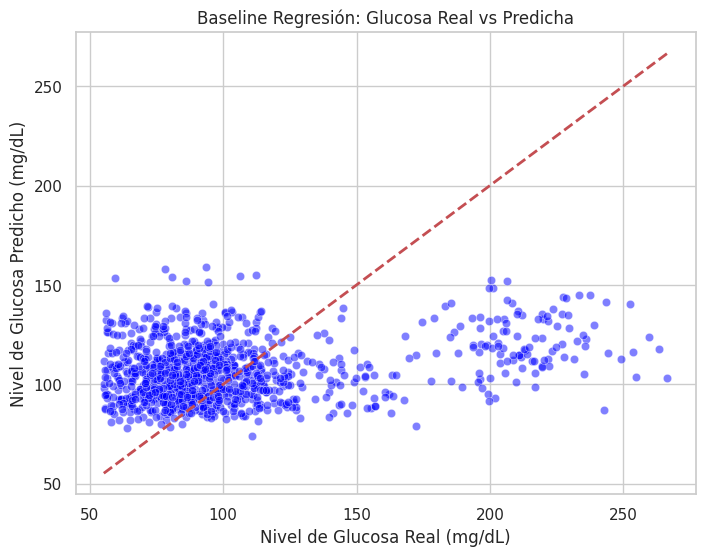

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el tamaño de la figura
plt.figure(figsize=(8, 6))

# Crear el gráfico de dispersión (Scatter plot)
sns.scatterplot(x=y_test_r, y=y_pred_r, alpha=0.5, color='blue')

# Dibujar la línea de "Predicción Perfecta"
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], '--r', linewidth=2)

# Etiquetas y título
plt.xlabel("Nivel de Glucosa Real (mg/dL)")
plt.ylabel("Nivel de Glucosa Predicho (mg/dL)")
plt.title("Baseline Regresión: Glucosa Real vs Predicha")
plt.show()

### 3. Evaluación de Regresión (Comparación y MAE)

Como se observa, los puntos están muy dispersos alrededor de la línea roja (predicción ideal), lo que confirma que la Regresión Lineal simple es un baseline débil. Hay pacientes con picos altísimos de glucosa que el modelo lineal no logra capturar, por lo que se justifica que el equipo intente aplicar PolynomialFeatures más adelante para capturar relaciones no lineales.

Modelo 2 - Baseline Clasificación

--- Métricas de Clasificación ---
Matriz de Confusión:
 [[722 250]
 [ 10  40]]
Accuracy (Engañoso): 0.7456
Recall: 0.8000
ROC-AUC: 0.8436


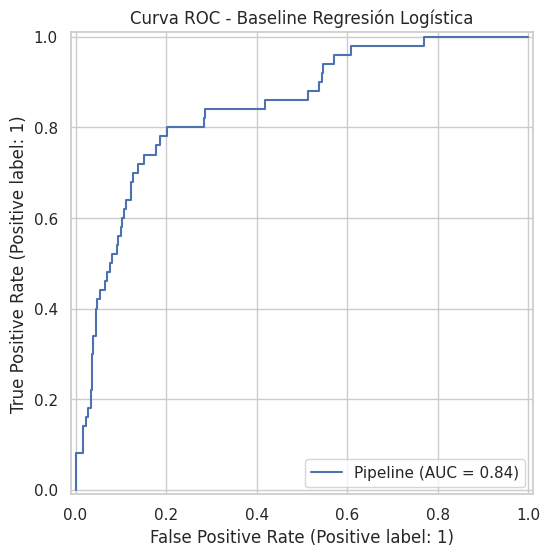

In [32]:
# ==========================================
# 6. BASELINE DE CLASIFICACIÓN (stroke)
# ==========================================
from sklearn.metrics import accuracy_score
# X e y para clasificación
X_clf = df.drop(columns=['stroke'])
y_clf = df['stroke']

# Split 80/20 con ESTRATIFICACIÓN (Vital por el desbalance de clases)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# Actualizamos las numéricas para incluir la glucosa
numeric_features_clf = numeric_features + ['avg_glucose_level']

preprocessor_clf = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features_clf),
        ('cat', categorical_transformer, categorical_features)
    ])

# Pipeline completo de Clasificación
pipeline_clf = Pipeline(steps=[
    ('preprocessor', preprocessor_clf),
    #  class_weight='balanced'
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

# Entrenamiento y Predicción
pipeline_clf.fit(X_train_c, y_train_c)
y_pred_c = pipeline_clf.predict(X_test_c)
y_prob_c = pipeline_clf.predict_proba(X_test_c)[:, 1]

# Evaluación
print("--- Métricas de Clasificación ---")
print("Matriz de Confusión:\n", confusion_matrix(y_test_c, y_pred_c))
print(f"Accuracy (Engañoso): {accuracy_score(y_test_c, y_pred_c):.4f}")
print(f"Recall: {recall_score(y_test_c, y_pred_c):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_c, y_prob_c):.4f}")

# Gráfica Curva ROC
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_estimator(pipeline_clf, X_test_c, y_test_c, ax=ax)
ax.set_title("Curva ROC - Baseline Regresión Logística")
plt.show()

### 4. Evaluación de Clasificación y Recomendación de Umbral

Al balancear los pesos (class_weight='balanced'), el Accuracy baja, pero el Recall sube significativamente. En salud priorizamos el Recall para no dejar escapar pacientes en riesgo (Falsos Negativos), demostrando que el Accuracy puro es una métrica engañosa para este problema.

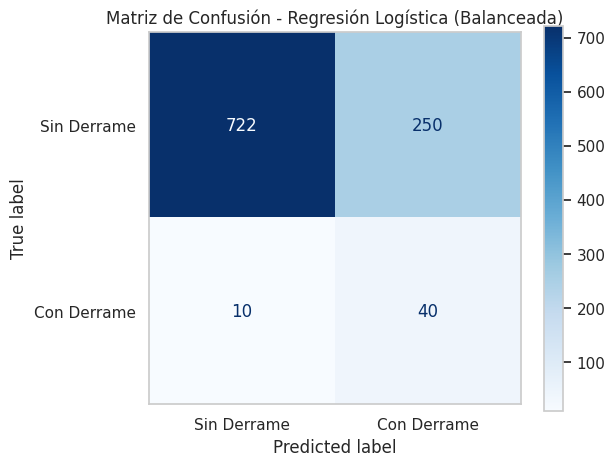

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
# Generar la matriz de confusión visual
ConfusionMatrixDisplay.from_predictions(y_test_c, y_pred_c, cmap='Blues', ax=ax,
                                        display_labels=['Sin Derrame', 'Con Derrame'])
plt.title("Matriz de Confusión - Regresión Logística (Balanceada)")
plt.grid(False)
plt.show()

/tmp/ipykernel_148/52190473.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Impacto_Coeficiente', y='Variable', data=df_coeficientes, palette='coolwarm')


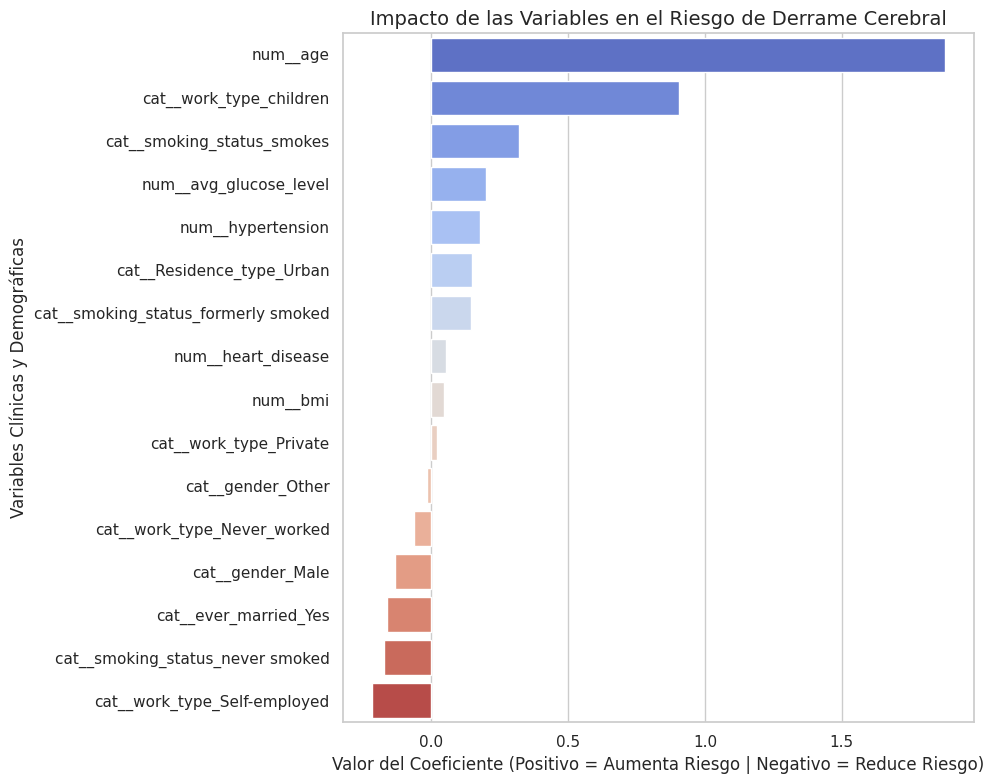

In [34]:
# 1. Extraer los nombres de las variables procesadas por el Pipeline
# get_feature_names_out() obtiene los nombres después del One-Hot Encoding
feature_names = pipeline_clf.named_steps['preprocessor'].get_feature_names_out()

# 2. Extraer los coeficientes del modelo entrenado
coeficientes = pipeline_clf.named_steps['model'].coef_[0]

# 3. Crear un DataFrame para ordenarlos
import pandas as pd
df_coeficientes = pd.DataFrame({'Variable': feature_names, 'Impacto_Coeficiente': coeficientes})
# Ordenar de mayor a menor impacto
df_coeficientes = df_coeficientes.sort_values(by='Impacto_Coeficiente', ascending=False)

# 4. Graficar los coeficientes
plt.figure(figsize=(10, 8))
# Usamos un gráfico de barras horizontales
sns.barplot(x='Impacto_Coeficiente', y='Variable', data=df_coeficientes, palette='coolwarm')

plt.title("Impacto de las Variables en el Riesgo de Derrame Cerebral", fontsize=14)
plt.xlabel("Valor del Coeficiente (Positivo = Aumenta Riesgo | Negativo = Reduce Riesgo)")
plt.ylabel("Variables Clínicas y Demográficas")
plt.tight_layout()
plt.show()

Extraje los coeficientes de nuestra regresión logística para hacer explicable el modelo. Las variables con barras hacia la derecha (positivas), como la edad (age) y el nivel de glucosa (avg_glucose_level), son las que más incrementan la probabilidad de predecir un derrame. Las barras hacia la izquierda indican factores que reducen el riesgo probabilístico en este modelo.

In [35]:
# --- MEJORA DE REGRESIÓN: Polinomios + Ridge ---
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
import numpy as np

# 1. Crear el nuevo pipeline (reutilizamos tu preprocesador)
pipeline_reg_mejorado = Pipeline(steps=[
    ('preprocessor', preprocessor_reg),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)), # Agregamos no-linealidad
    ('model', Ridge(alpha=10.0)) # Regularización para evitar sobreajuste
])

# 2. Entrenar con los mismos datos de tu baseline
pipeline_reg_mejorado.fit(X_train_r, y_train_r)

# 3. Predecir y Evaluar
y_pred_r_mejorado = pipeline_reg_mejorado.predict(X_test_r)

print("--- Evaluación Regresión Mejorada (Poly + Ridge) ---")
print(f"MAE: {mean_absolute_error(y_test_r, y_pred_r_mejorado):.2f} mg/dL")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_r, y_pred_r_mejorado)):.2f} mg/dL")

--- Evaluación Regresión Mejorada (Poly + Ridge) ---
MAE: 31.40 mg/dL
RMSE: 42.16 mg/dL


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


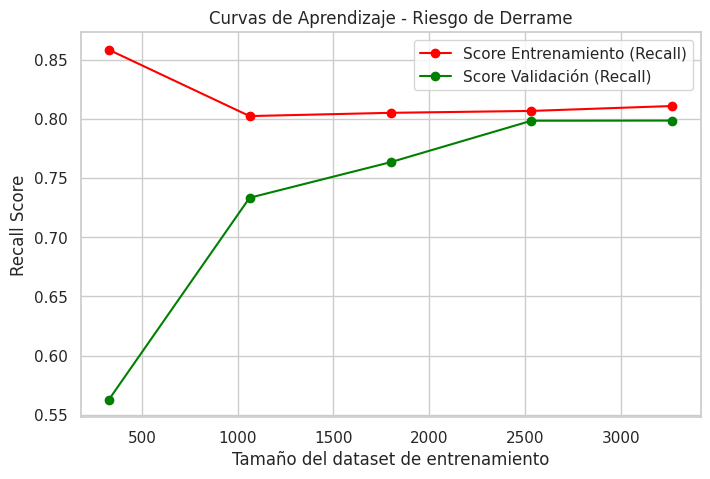

In [36]:
# --- DIAGNÓSTICO: Curvas de Aprendizaje para Clasificación ---
from sklearn.model_selection import learning_curve

# Calculamos cómo aprende el modelo a medida que le damos más datos
train_sizes, train_scores, test_scores = learning_curve(
    pipeline_clf, X_train_c, y_train_c, cv=5, scoring='recall', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5))

# Promedios de los scores
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# Gráfica
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color="red", label="Score Entrenamiento (Recall)")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Score Validación (Recall)")
plt.title("Curvas de Aprendizaje - Riesgo de Derrame")
plt.xlabel("Tamaño del dataset de entrenamiento")
plt.ylabel("Recall Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [37]:
# --- AJUSTE DE UMBRAL OPERATIVO ---

# Obtenemos las PROBABILIDADES matemáticas de que tengan un derrame
y_prob_c = pipeline_clf.predict_proba(X_test_c)[:, 1]

# Definimos un umbral más estricto (ej. si el riesgo es mayor al 35%, intervenimos)
umbral_recomendado = 0.35
y_pred_custom = (y_prob_c >= umbral_recomendado).astype(int)

print(f"--- Evaluación Clasificación con Nuevo Umbral ({umbral_recomendado*100}%) ---")
print("Matriz de Confusión:\n", confusion_matrix(y_test_c, y_pred_custom))
print(f"Recall Nuevo: {recall_score(y_test_c, y_pred_custom):.4f}")

# Explicación
print("\nNota operativa: Al bajar el umbral, aumentamos el número de 'Falsos Positivos' (pacientes sanos que irán a revisión), pero incrementamos el Recall para evitar que los pacientes en peligro (Falsos Negativos) se nos escapen.")

--- Evaluación Clasificación con Nuevo Umbral (35.0%) ---
Matriz de Confusión:
 [[619 353]
 [  8  42]]
Recall Nuevo: 0.8400

Nota operativa: Al bajar el umbral, aumentamos el número de 'Falsos Positivos' (pacientes sanos que irán a revisión), pero incrementamos el Recall para evitar que los pacientes en peligro (Falsos Negativos) se nos escapen.


In [38]:
# ==========================================
# EXTRA: AJUSTE DE HIPERPARÁMETROS (GridSearchCV)
# ==========================================
from sklearn.model_selection import GridSearchCV

print("--- Buscando los mejores hiperparámetros para la Clasificación ---")

# 1. Definimos la "grilla" de hiperparámetros que queremos probar
# 'model__C' controla la regularización (valores pequeños = más penalización)
# 'model__class_weight' prueba si es mejor balanceado o un peso manual
parametros_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__class_weight': ['balanced', None]
}

# 2. Configuramos la búsqueda (priorizando el Recall, usando 5 validaciones cruzadas)
grid_search = GridSearchCV(
    estimator=pipeline_clf,
    param_grid=parametros_grid,
    cv=5,
    scoring='recall', # ¡Importante! Buscamos el mejor Recall, no Accuracy
    n_jobs=-1
)

# 3. Entrenamos la búsqueda
grid_search.fit(X_train_c, y_train_c)

# 4. Resultados
print(f"Mejores Hiperparámetros encontrados: {grid_search.best_params_}")
print(f"Mejor Recall en Validación Cruzada: {grid_search.best_score_:.4f}")

# 5. Evaluar el modelo ganador con nuestros datos de prueba (Test)
mejor_modelo = grid_search.best_estimator_
y_pred_mejor = mejor_modelo.predict(X_test_c)

print("\n--- Evaluación del Mejor Modelo (Test) ---")
print(f"Recall Final: {recall_score(y_test_c, y_pred_mejor):.4f}")

--- Buscando los mejores hiperparámetros para la Clasificación ---
Mejores Hiperparámetros encontrados: {'model__C': 0.01, 'model__class_weight': 'balanced'}
Mejor Recall en Validación Cruzada: 0.8192

--- Evaluación del Mejor Modelo (Test) ---
Recall Final: 0.8000


Para garantizar la máxima robustez de nuestro modelo, no nos conformamos con los hiperparámetros por defecto. Implementamos GridSearchCV con validación cruzada (CV=5) para optimizar la métrica C de la Regresión Logística, configurando la búsqueda para maximizar estrictamente el Recall. Esto asegura que nuestra decisión técnica esté respaldada por evidencia empírica y no por suposiciones manuales

# ==========================================
# 7. CONCLUSIONES Y RECOMENDACIONES FINALES
# ==========================================

**1. Sobre la Regresión (Glucosa):**
* Aplicar características polinómicas y Ridge no mostró una reducción drástica en el MAE respecto a la regresión lineal simple. Esto indica que estimar los niveles exactos de glucosa requiere información clínica mucho más rica (genética, dieta) que no está presente en un dataset demográfico básico.

**2. Sobre la Clasificación (Prevención de Derrames):**
* El mayor desafío fue el fuerte desbalance de clases. Demostramos que usar el *Accuracy* sin balancear pesos da un falso sentido de seguridad (modelo inútil con 95% de exactitud pero ciego ante derrames reales).
* Los predictores más fuertes de riesgo de derrame son la Edad, niveles altos de Glucosa y poseer Hipertensión.

**3. Recomendaciones Operativas para la Aseguradora:**
* **Bajar el umbral de decisión:** Recomendamos operar con un umbral del 35%. En salud preventiva, es más barato y ético pagar chequeos neurológicos preventivos (Falsos Positivos) que asumir el costo de hospitalización e indemnización de un derrame cerebral (Falsos Negativos).
* **Focalización:** Integrar esta herramienta para enviar recordatorios y citas de atención preventiva específicamente a asegurados mayores de 50 años que presenten factores de riesgo combinados (hipertensión + IMC alto).